Import Libraries

In [8]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

Load Sample Audio for Testing

In [10]:
import librosa

file_path = librosa.ex('trumpet')
y, sr = librosa.load(file_path)

print(f"Sample rate: {sr}, Audio duration: {len(y)/sr:.2f} seconds")

C:\Users\ghwns\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Sample rate: 22050, Audio duration: 5.33 seconds


Extract Bass-Focused Features from Audio (STFT & Spectrogram)

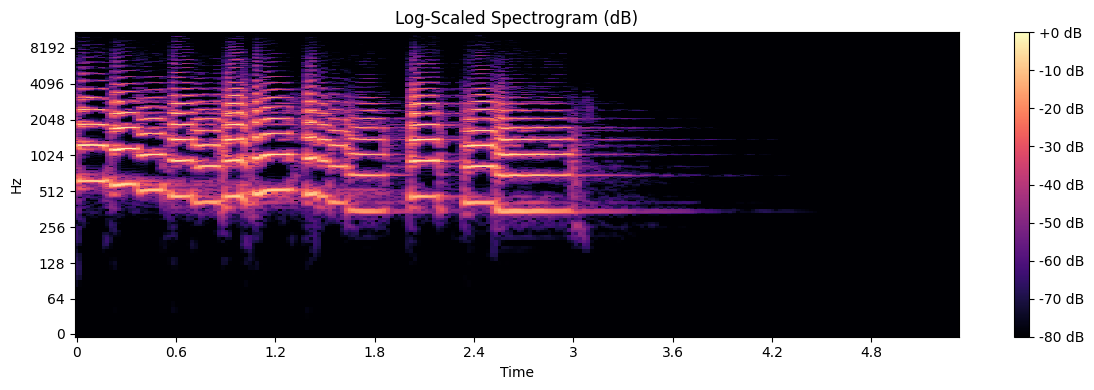

In [11]:
import matplotlib.pyplot as plt
import librosa.display

D = np.abs(librosa.stft(y))

DB = librosa.amplitude_to_db(D, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(DB, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Scaled Spectrogram (dB)")
plt.tight_layout()
plt.show()

Compute Bass Energy (60–250 Hz Band)

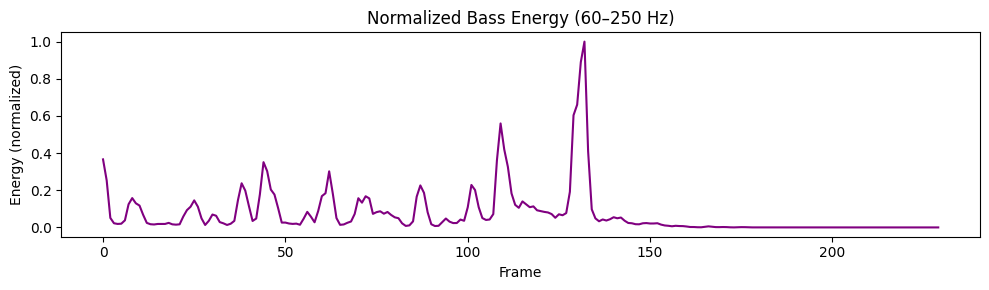

In [12]:
D = np.abs(librosa.stft(y))
frequencies = librosa.fft_frequencies(sr=sr)

bass_range = np.where((frequencies >= 60) & (frequencies <= 250))[0]

bass_energy = np.sum(D[bass_range, :], axis=0)

bass_energy_norm = bass_energy / np.max(bass_energy)

plt.figure(figsize=(10, 3))
plt.plot(bass_energy_norm, color='purple')
plt.title("Normalized Bass Energy (60–250 Hz)")
plt.xlabel("Frame")
plt.ylabel("Energy (normalized)")
plt.tight_layout()
plt.show()

Summarize Bass Feature (Mean, Std, etc.)

In [13]:
bass_mean = np.mean(bass_energy)
bass_std = np.std(bass_energy)
bass_max = np.max(bass_energy)
bass_min = np.min(bass_energy)

print(f"Bass Energy Summary:")
print(f"- Mean: {bass_mean:.2f}")
print(f"- Std: {bass_std:.2f}")
print(f"- Max: {bass_max:.2f}")
print(f"- Min: {bass_min:.2f}")

# Optional: Save as vector for similarity comparison
#bass_vector = np.array([bass_mean, bass_std, bass_max, bass_min])

Bass Energy Summary:
- Mean: 0.11
- Std: 0.20
- Max: 1.52
- Min: 0.00
